✅ Connecting to Data Warehouse...
🎉 Connection Successful! Ready to query.
--- Price Data ---


,event_time,symbol,last_price,volume_24h
0,2025-12-08 06:30:45.183611,BTC_THB,2770048.79,140.91463


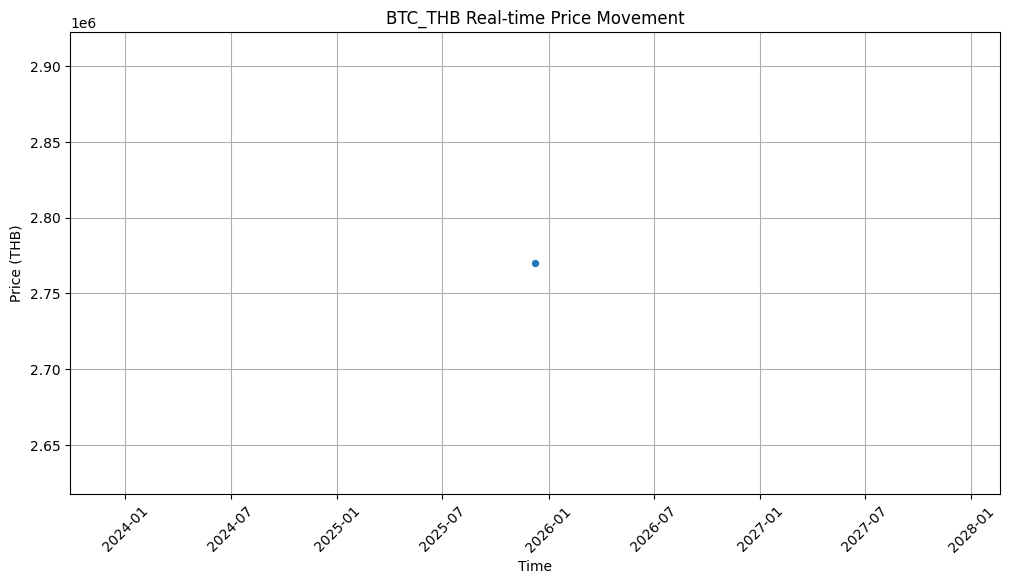

--- Order Data ---


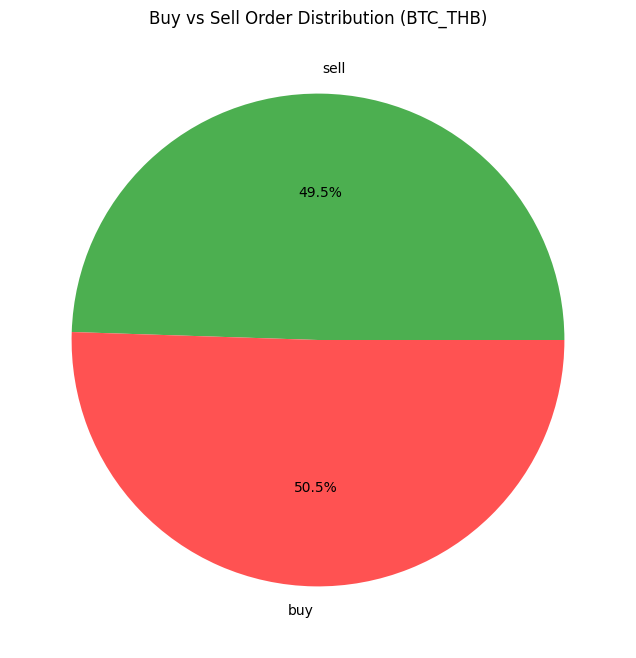

--- Audit Logs ---


,event_time,actor_id,action,resource


In [20]:
# !pip install pandas sqlalchemy psycopg2-binary matplotlib seaborn
# รัน Cell นี้ครั้งเดียวเพื่อติดตั้ง Library (ถ้ารันใน Jupyter ให้เอา # ออก)
# %pip install matplotlib seaborn pandas sqlalchemy psycopg2-binary

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 1. Config Connection ---
DB_USER = 'warehouse_admin'
DB_PASS = 'warehouse_password'
DB_HOST = 'localhost'
DB_PORT = '5433' # ถูกต้องครับ ใช้ 5433 เข้าจากเครื่องเรา
DB_NAME = 'bitka_dw'

# สร้าง Connection String
connection_str = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_str)

print("✅ Connecting to Data Warehouse...")
try:
    with engine.connect() as conn:
        print("🎉 Connection Successful! Ready to query.")
except Exception as e:
    print(f"❌ Connection Failed: {e}")

# --- 2. Query Data: Price Trend ---
# แก้ชื่อตารางเป็น tickers และเวลาเป็น updated_at
sql_price = """
SELECT 
    updated_at as event_time, 
    symbol, 
    last_price, 
    volume_24h 
FROM tickers 
WHERE symbol = 'BTC_THB' 
ORDER BY updated_at DESC 
LIMIT 100
"""

# โหลดเข้า DataFrame
df_price = pd.read_sql(sql_price, engine)

if not df_price.empty:
    # แปลงประเภทข้อมูล
    df_price['last_price'] = df_price['last_price'].astype(float)
    df_price['event_time'] = pd.to_datetime(df_price['event_time'])

    # แสดงข้อมูล 5 แถวแรก
    print("--- Price Data ---")
    display(df_price.head())

    # --- 3. Visualization ---
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_price, x='event_time', y='last_price', marker='o')
    plt.title('BTC_THB Real-time Price Movement')
    plt.xlabel('Time')
    plt.ylabel('Price (THB)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
else:
    print("⚠️ No Price Data found yet.")

# --- 4. Query Data: Order Side Analysis ---
# แก้ชื่อตารางเป็น orders
sql_orders = """
SELECT 
    side, 
    COUNT(*) as order_count,
    SUM(quantity * price) as total_value_thb
FROM orders
WHERE symbol = 'BTC_THB'
GROUP BY side
"""

df_orders = pd.read_sql(sql_orders, engine)

if not df_orders.empty:
    # --- 5. Visualization: Pie Chart ---
    print("--- Order Data ---")
    plt.figure(figsize=(8, 8))
    plt.pie(df_orders['order_count'], labels=df_orders['side'], autopct='%1.1f%%', colors=['#4CAF50', '#FF5252'])
    plt.title('Buy vs Sell Order Distribution (BTC_THB)')
    plt.show()
else:
    print("⚠️ No Order Data found yet.")

# --- 6. Query Data: Audit ---
# แก้ชื่อตารางเป็น audit_logs และเอา severity ออก (เพราะใน init.sql เราไม่ได้สร้างไว้)
sql_audit = """
SELECT 
    created_at as event_time, 
    actor_id, 
    action,
    resource
FROM audit_logs 
ORDER BY created_at DESC
LIMIT 20
"""

df_audit = pd.read_sql(sql_audit, engine)
print("--- Audit Logs ---")
display(df_audit)